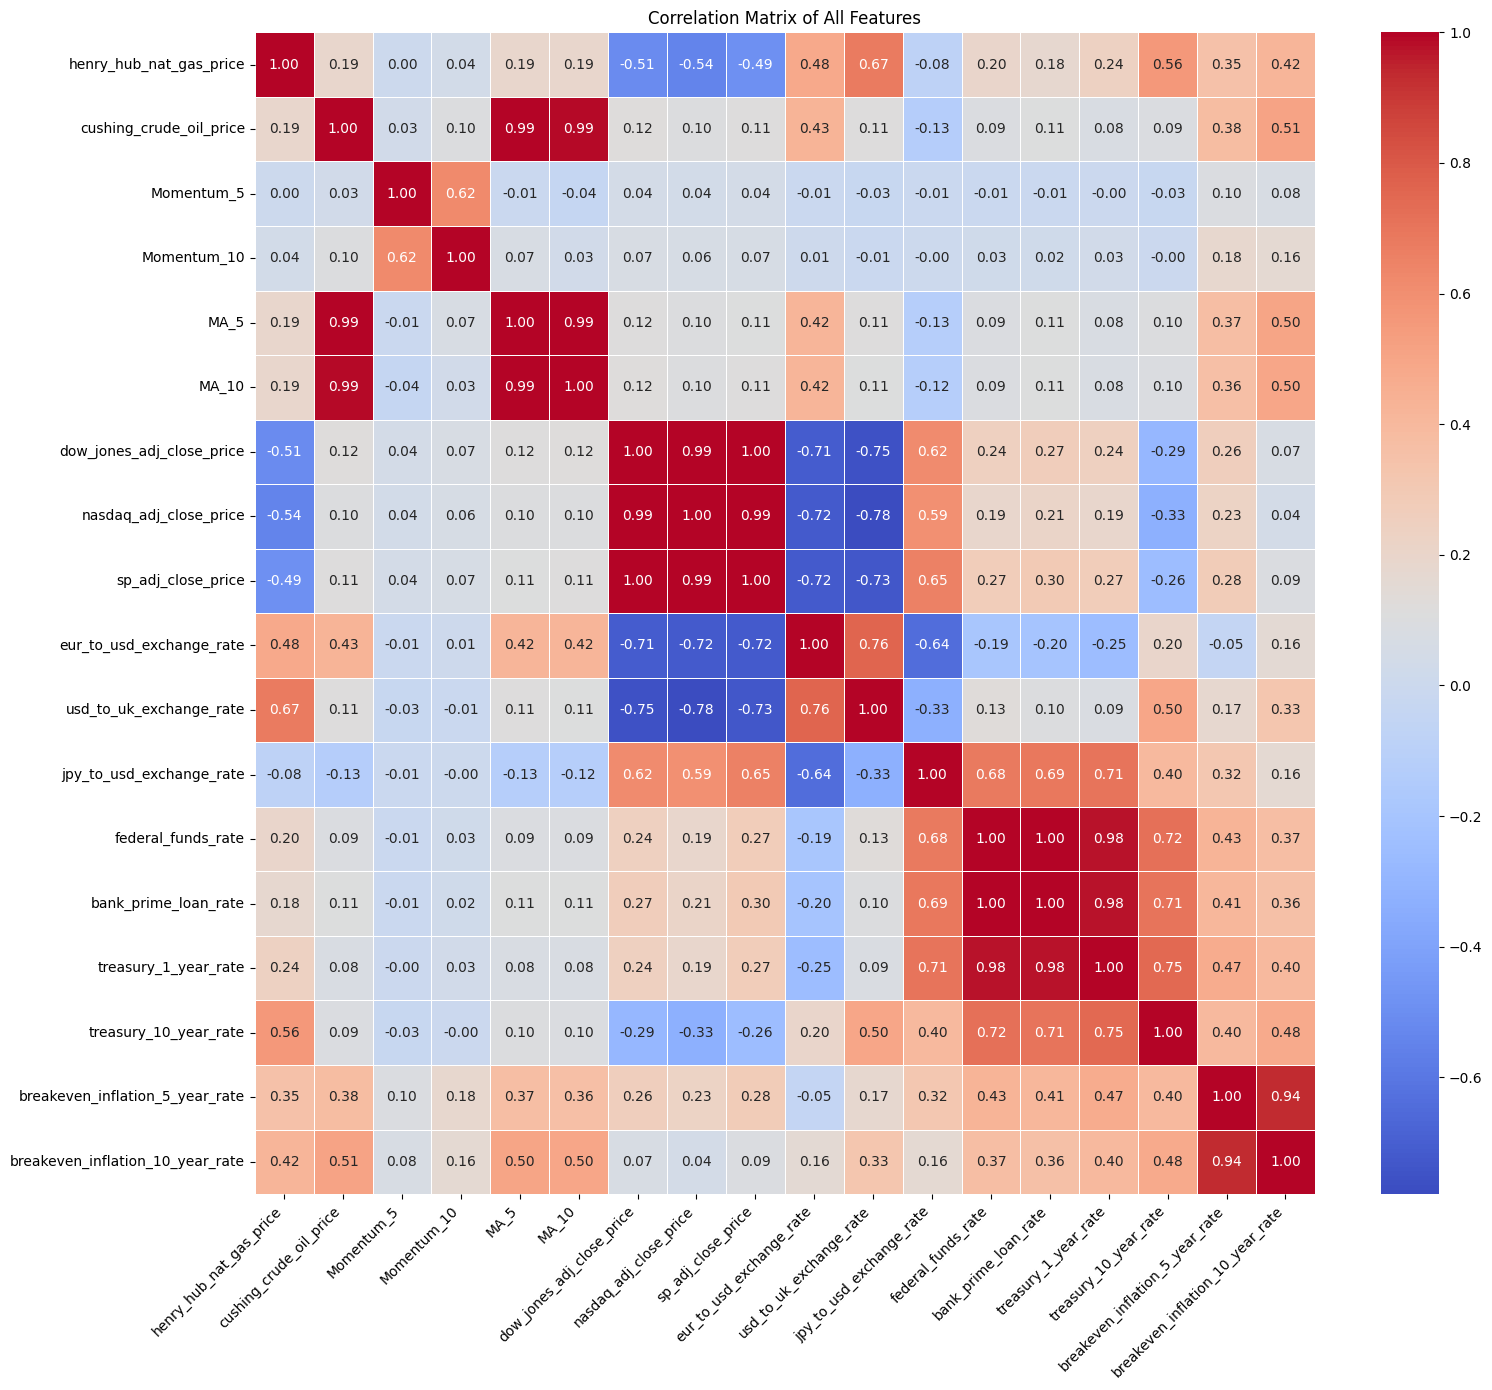

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('compiled_dataset.csv')

# Lọc các cột số để tính tương quan
numerical_df = df.select_dtypes(include=[np.number])

# Tính ma trận tương quan
corr_matrix = numerical_df.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of All Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

Version 1

Epoch [1/50] - Train Loss: 0.047747, Test Loss: 0.018833
Epoch [2/50] - Train Loss: 0.012920, Test Loss: 0.020801
Epoch [3/50] - Train Loss: 0.004060, Test Loss: 0.001056
Epoch [4/50] - Train Loss: 0.000332, Test Loss: 0.000352
Epoch [5/50] - Train Loss: 0.000144, Test Loss: 0.000248
Epoch [6/50] - Train Loss: 0.000127, Test Loss: 0.000229
Epoch [7/50] - Train Loss: 0.000122, Test Loss: 0.000199
Epoch [8/50] - Train Loss: 0.000124, Test Loss: 0.000306
Epoch [9/50] - Train Loss: 0.000160, Test Loss: 0.000325
Epoch [10/50] - Train Loss: 0.000129, Test Loss: 0.000443
Epoch [11/50] - Train Loss: 0.000142, Test Loss: 0.000371
Epoch [12/50] - Train Loss: 0.000122, Test Loss: 0.000213
Epoch [13/50] - Train Loss: 0.000129, Test Loss: 0.000274
Epoch [14/50] - Train Loss: 0.000153, Test Loss: 0.000130
Epoch [15/50] - Train Loss: 0.000127, Test Loss: 0.000195
Epoch [16/50] - Train Loss: 0.000126, Test Loss: 0.000098
Epoch [17/50] - Train Loss: 0.000141, Test Loss: 0.000093
Epoch [18/50] - Train L

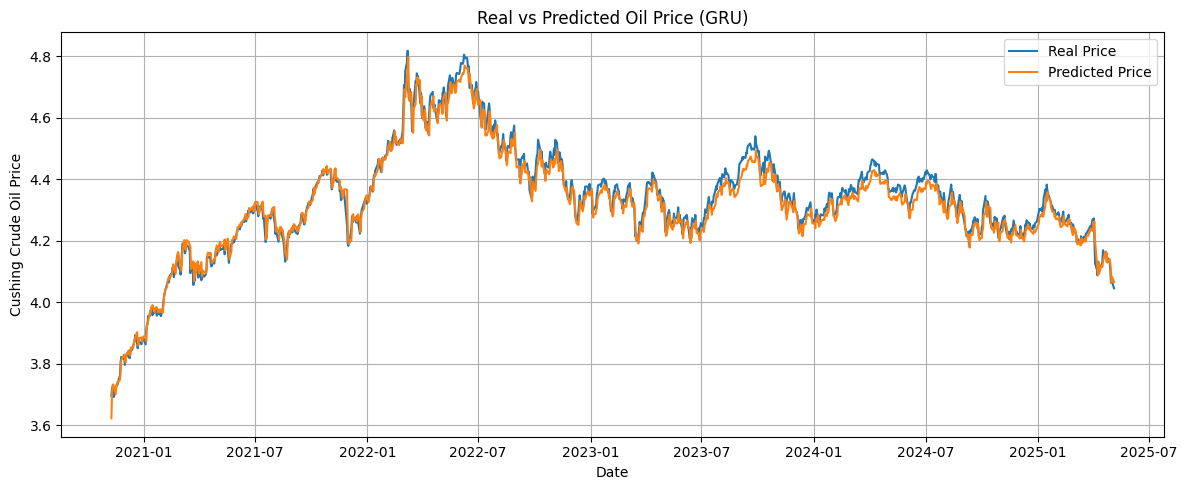

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('compiled_dataset.csv', parse_dates=['Date'])

features = [
    "Date",
    'dow_jones_adj_close_price',
    'nasdaq_adj_close_price',
    'sp_adj_close_price',
    'usd_to_uk_exchange_rate',
    'treasury_1_year_rate',
    'breakeven_inflation_5_year_rate',
    'bank_prime_loan_rate',
    'federal_funds_rate',
]

target = 'cushing_crude_oil_price'

data = df[features + [target]].copy()
data = data.sort_values('Date').reset_index(drop=True)

feature_cols = [
    'dow_jones_adj_close_price',
    'nasdaq_adj_close_price',
    'sp_adj_close_price',
    'usd_to_uk_exchange_rate',
    'treasury_1_year_rate',
    'breakeven_inflation_5_year_rate',
    'bank_prime_loan_rate',
    'federal_funds_rate',
    'cushing_crude_oil_price',
]

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

features_values = data[feature_cols].values
target_values = data[[target]].values

scaled_features = feature_scaler.fit_transform(features_values)
scaled_target = target_scaler.fit_transform(target_values)

dates = data['Date'].values

def create_sequences(features_arr, target_arr, lookback=30):
    X_list = []
    y_list = []
    for i in range(lookback, len(features_arr)):
        X_list.append(features_arr[i - lookback:i])
        y_list.append(target_arr[i])
    X = np.array(X_list)
    y = np.array(y_list)
    return X, y

lookback = 1
X, y = create_sequences(scaled_features, scaled_target, lookback=lookback)
sample_dates = dates[lookback:]

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]
X_test = X[train_size:]
y_test = y[train_size:]

dates_train = sample_dates[:train_size]
dates_test = sample_dates[train_size:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1):
        super(GRURegressor, self).__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

input_size = X_train.shape[-1]
hidden_size = 32
num_layers = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRURegressor(input_size, hidden_size, num_layers).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.007586)

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_dataset)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item() * batch_X.size(0)
    test_loss /= len(test_dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_loss:.6f}, Test Loss: {test_loss:.6f}")

checkpoint = {
    "model_state_dict": model.state_dict(),
    "feature_scaler": feature_scaler,
    "target_scaler": target_scaler,
    "lookback": lookback,
    "input_size": input_size,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
}
torch.save(checkpoint, "gru_oil_price_checkpoint.pth")
print("Checkpoint saved to gru_oil_price_checkpoint.pth")

model.eval()
with torch.no_grad():
    X_test_t = X_test_t.to(device)
    y_pred_scaled = model(X_test_t).cpu().numpy()

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_test_real = target_scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print("Test MAE :", mae)
print("Test RMSE:", rmse)
print("Test R^2 :", r2)

plt.figure(figsize=(12, 5))
plt.plot(dates_test, y_test_real.flatten(), label="Real Price")
plt.plot(dates_test, y_pred.flatten(), label="Predicted Price")
plt.xlabel("Date")
plt.ylabel("Cushing Crude Oil Price")
plt.title("Real vs Predicted Oil Price (GRU)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Version 2

Original shape: (5609, 6)
Shape after dropping NaNs: (5609, 6)
Epoch [1/50] - Train Loss: 0.037491, Test Loss: 0.012203
Epoch [2/50] - Train Loss: 0.010302, Test Loss: 0.002009
Epoch [3/50] - Train Loss: 0.001644, Test Loss: 0.000299
Epoch [4/50] - Train Loss: 0.000356, Test Loss: 0.000241
Epoch [5/50] - Train Loss: 0.000333, Test Loss: 0.000320
Epoch [6/50] - Train Loss: 0.000338, Test Loss: 0.000271
Epoch [7/50] - Train Loss: 0.000327, Test Loss: 0.000268
Epoch [8/50] - Train Loss: 0.000322, Test Loss: 0.000515
Epoch [9/50] - Train Loss: 0.000357, Test Loss: 0.000232
Epoch [10/50] - Train Loss: 0.000313, Test Loss: 0.000225
Epoch [11/50] - Train Loss: 0.000325, Test Loss: 0.000531
Epoch [12/50] - Train Loss: 0.000357, Test Loss: 0.000222
Epoch [13/50] - Train Loss: 0.000303, Test Loss: 0.000230
Epoch [14/50] - Train Loss: 0.000311, Test Loss: 0.000491
Epoch [15/50] - Train Loss: 0.000360, Test Loss: 0.000222
Epoch [16/50] - Train Loss: 0.000335, Test Loss: 0.000505
Epoch [17/50] - Tr

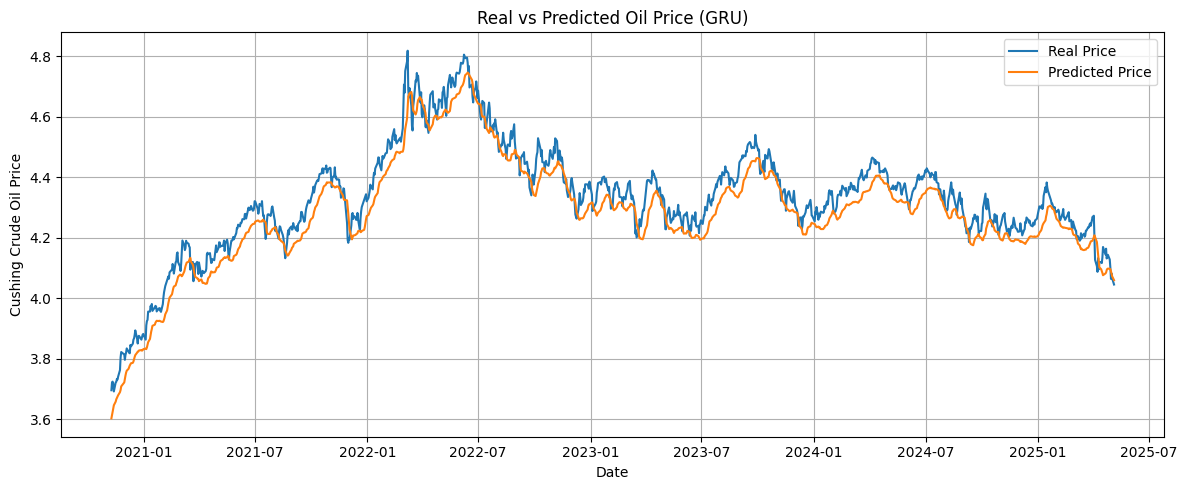

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('compiled_dataset.csv', parse_dates=['Date'])

features = [
    "Date",
    'MA_5',                             
    'MA_10',                            
    'breakeven_inflation_10_year_rate', 
    #'eur_to_usd_exchange_rate',         
    'breakeven_inflation_5_year_rate'
]

target = 'cushing_crude_oil_price'

data = df[features + [target]].copy()
data = data.sort_values('Date').reset_index(drop=True)

print(f"Original shape: {data.shape}")
data = data.dropna()
print(f"Shape after dropping NaNs: {data.shape}")

feature_cols = [
    'MA_5',                             
    'MA_10',                            
    'breakeven_inflation_10_year_rate', 
    #'eur_to_usd_exchange_rate',         
    'breakeven_inflation_5_year_rate'
]

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

features_values = data[feature_cols].values
target_values = data[[target]].values

scaled_features = feature_scaler.fit_transform(features_values)
scaled_target = target_scaler.fit_transform(target_values)

dates = data['Date'].values

def create_sequences(features_arr, target_arr, lookback=30):
    X_list = []
    y_list = []
    for i in range(lookback, len(features_arr)):
        X_list.append(features_arr[i - lookback:i])
        y_list.append(target_arr[i])
    X = np.array(X_list)
    y = np.array(y_list)
    return X, y

lookback = 1
X, y = create_sequences(scaled_features, scaled_target, lookback=lookback)
sample_dates = dates[lookback:]

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]
X_test = X[train_size:]
y_test = y[train_size:]

dates_train = sample_dates[:train_size]
dates_test = sample_dates[train_size:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1):
        super(GRURegressor, self).__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

input_size = X_train.shape[-1]
hidden_size = 32
num_layers = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRURegressor(input_size, hidden_size, num_layers).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.007586)

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_dataset)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item() * batch_X.size(0)
    test_loss /= len(test_dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_loss:.6f}, Test Loss: {test_loss:.6f}")

checkpoint = {
    "model_state_dict": model.state_dict(),
    "feature_scaler": feature_scaler,
    "target_scaler": target_scaler,
    "lookback": lookback,
    "input_size": input_size,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
}

torch.save(checkpoint, "gru_oil_price_checkpoint.pth")
print("Checkpoint saved to gru_oil_price_checkpoint.pth")

model.eval()
with torch.no_grad():
    X_test_t = X_test_t.to(device)
    y_pred_scaled = model(X_test_t).cpu().numpy()

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_test_real = target_scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print("Test MAE :", mae)
print("Test RMSE:", rmse)
print("Test R^2 :", r2)

plt.figure(figsize=(12, 5))
plt.plot(dates_test, y_test_real.flatten(), label="Real Price")
plt.plot(dates_test, y_pred.flatten(), label="Predicted Price")
plt.xlabel("Date")
plt.ylabel("Cushing Crude Oil Price")
plt.title("Real vs Predicted Oil Price (GRU)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Version 3

Original shape: (5609, 17)
Shape after dropping NaNs: (5609, 17)
Epoch [1/50] - Train Loss: 0.064775, Test Loss: 0.013656
Epoch [2/50] - Train Loss: 0.012960, Test Loss: 0.011362
Epoch [3/50] - Train Loss: 0.007397, Test Loss: 0.009122
Epoch [4/50] - Train Loss: 0.001807, Test Loss: 0.001365
Epoch [5/50] - Train Loss: 0.000693, Test Loss: 0.000579
Epoch [6/50] - Train Loss: 0.000385, Test Loss: 0.000354
Epoch [7/50] - Train Loss: 0.000299, Test Loss: 0.000375
Epoch [8/50] - Train Loss: 0.000273, Test Loss: 0.000653
Epoch [9/50] - Train Loss: 0.000255, Test Loss: 0.000961
Epoch [10/50] - Train Loss: 0.000276, Test Loss: 0.000287
Epoch [11/50] - Train Loss: 0.000283, Test Loss: 0.000365
Epoch [12/50] - Train Loss: 0.000259, Test Loss: 0.000327
Epoch [13/50] - Train Loss: 0.000240, Test Loss: 0.000308
Epoch [14/50] - Train Loss: 0.000239, Test Loss: 0.000713
Epoch [15/50] - Train Loss: 0.000236, Test Loss: 0.000496
Epoch [16/50] - Train Loss: 0.000230, Test Loss: 0.000375
Epoch [17/50] - 

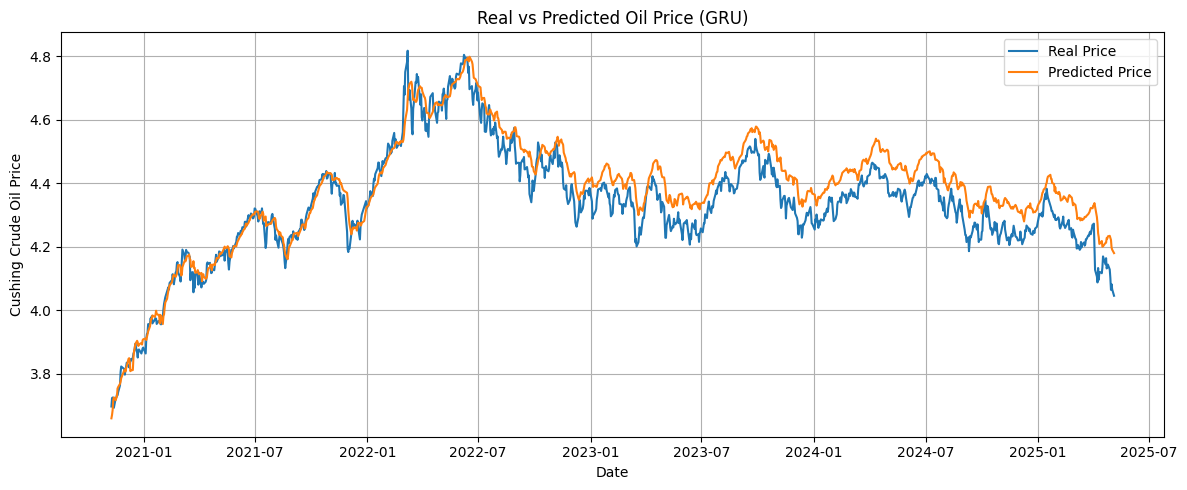

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('compiled_dataset.csv', parse_dates=['Date'])

features = [
    'Date',
    'MA_5', 
    'MA_10', 
    'breakeven_inflation_10_year_rate', 
    #'eur_to_usd_exchange_rate', 
    'breakeven_inflation_5_year_rate',
    'henry_hub_nat_gas_price',
    'dow_jones_adj_close_price', 
    'sp_adj_close_price',
    'usd_to_uk_exchange_rate',
    'bank_prime_loan_rate',
    'nasdaq_adj_close_price',
    'Momentum_10',
    'federal_funds_rate',
    'treasury_10_year_rate',
    'treasury_1_year_rate',
    'Momentum_5'
]

target = 'cushing_crude_oil_price'

data = df[features + [target]].copy()
data = data.sort_values('Date').reset_index(drop=True)

print(f"Original shape: {data.shape}")
data = data.dropna()
print(f"Shape after dropping NaNs: {data.shape}")

feature_cols = [
    'MA_5', 
    'MA_10', 
    'breakeven_inflation_10_year_rate', 
    #'eur_to_usd_exchange_rate', 
    'breakeven_inflation_5_year_rate',
    'henry_hub_nat_gas_price',
    'dow_jones_adj_close_price', 
    'sp_adj_close_price',
    'usd_to_uk_exchange_rate',
    'bank_prime_loan_rate',
    'nasdaq_adj_close_price',
    'Momentum_10',
    'federal_funds_rate',
    'treasury_10_year_rate',
    'treasury_1_year_rate',
    'Momentum_5'
]

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

features_values = data[feature_cols].values
target_values = data[[target]].values

scaled_features = feature_scaler.fit_transform(features_values)
scaled_target = target_scaler.fit_transform(target_values)

dates = data['Date'].values

def create_sequences(features_arr, target_arr, lookback=30):
    X_list = []
    y_list = []
    for i in range(lookback, len(features_arr)):
        X_list.append(features_arr[i - lookback:i])
        y_list.append(target_arr[i])
    X = np.array(X_list)
    y = np.array(y_list)
    return X, y

lookback = 1
X, y = create_sequences(scaled_features, scaled_target, lookback=lookback)
sample_dates = dates[lookback:]

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]
X_test = X[train_size:]
y_test = y[train_size:]

dates_train = sample_dates[:train_size]
dates_test = sample_dates[train_size:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1):
        super(GRURegressor, self).__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

input_size = X_train.shape[-1]
hidden_size = 32
num_layers = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRURegressor(input_size, hidden_size, num_layers).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.007586)

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_dataset)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item() * batch_X.size(0)
    test_loss /= len(test_dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_loss:.6f}, Test Loss: {test_loss:.6f}")

checkpoint = {
    "model_state_dict": model.state_dict(),
    "feature_scaler": feature_scaler,
    "target_scaler": target_scaler,
    "lookback": lookback,
    "input_size": input_size,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
}

torch.save(checkpoint, "gru_oil_price_checkpoint.pth")
print("Checkpoint saved to gru_oil_price_checkpoint.pth")

model.eval()
with torch.no_grad():
    X_test_t = X_test_t.to(device)
    y_pred_scaled = model(X_test_t).cpu().numpy()

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_test_real = target_scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print("Test MAE :", mae)
print("Test RMSE:", rmse)
print("Test R^2 :", r2)

plt.figure(figsize=(12, 5))
plt.plot(dates_test, y_test_real.flatten(), label="Real Price")
plt.plot(dates_test, y_pred.flatten(), label="Predicted Price")
plt.xlabel("Date")
plt.ylabel("Cushing Crude Oil Price")
plt.title("Real vs Predicted Oil Price (GRU)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
